# 05 - Metrics, Kinematic Extraction, and Plots

This notebook performs the **post-processing of results obtained with DeepLabCut**.

## Objectives

- Read the `.h5` files generated by the trained model  
- Compute the **beam angle** from the tracked keypoints  
- Filter the angular signal  
- Estimate the **angular velocity**  
- Save the video kinematic results to a CSV file  
- Compare the signal obtained through **computer vision** with the signal measured by the system (`.mat`)  
- Compute **error metrics**  
- Generate final plots for the experiments

## Important Note

In this notebook, the signals obtained from the video are first computed **independently**:

- $\theta$ &nbsp;&nbsp;: Initial angular displacement
- $\theta_f$ : Final angular displacement
- $\omega$ &nbsp;&nbsp;: Initial angular velocity
- $\omega_f$ : Final angular velocity

The synchronization parameters:

- `video_start_s`  
- `video_end_s`  
- `video_offset_s`  

are used **only during the final comparison step** with the `.mat` file.

Therefore, the temporal cropping does **not interfere with the kinematic calculations** already performed.

## 1. Imports and Path Setup

In [1]:
# ==========================================================
# IMPORTS
# ==========================================================

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import savgol_filter

# ==========================================================
# PROJECT BASE PATH
# ==========================================================
# Considering the following structure:
# DLC_projects4/
# ├── notebooks/
# ├── videos/
# ├── results/
# ├── src/
# └── ...

ROOT_NOTEBOOK = Path.cwd().resolve().parent
if str(ROOT_NOTEBOOK) not in sys.path:
    sys.path.append(str(ROOT_NOTEBOOK))

# ==========================================================
# PROJECTS DIRECTORIES
# ==========================================================

ROOT_DIR = ROOT_NOTEBOOK
VIDEOS_DIR = ROOT_DIR / "videos"
RESULTS_DIR = ROOT_DIR / "results"

FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"
COMPARISONS_DIR = RESULTS_DIR / "comparisons"
THETA_VALIDATION_DIR = COMPARISONS_DIR / "theta_validation_rad"

# Folder containing the .mat files
# Adjust this if your .mat files are located in another folder
MAT_DIR = ROOT_DIR / "dados_mat"

# Create directories if necessary
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
COMPARISONS_DIR.mkdir(parents=True, exist_ok=True)
THETA_VALIDATION_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT_DIR:", ROOT_DIR)
print("VIDEOS_DIR:", VIDEOS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("MAT_DIR:", MAT_DIR)
print("THETA_VALIDATION_DIR:", THETA_VALIDATION_DIR)

ROOT_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1
VIDEOS_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\videos
RESULTS_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\results
MAT_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\dados_mat
THETA_VALIDATION_DIR: C:\Users\edoal\ProjetosPy\bab_dlc1\results\comparisons\theta_validation_rad


### Cell 2 — Global Parameters

In [8]:
# ==========================================================
# GLOBAL PARAMETERS
# ==========================================================

FPS = 30.0

# keypoint likehood
PCUT = 0.6

# remove offset before metrics calculation
REMOVE_DC_BEFORE_ERROR = True

print("FPS =", FPS)
print("PCUT =", PCUT)

FPS = 30.0
PCUT = 0.6


## Formulation

The bar's orientation is derived from two keypoints tracked by DeepLabCut:

- left end: $(x_{left}, y_{left})$
- right end: $(x_{right}, y_{right})$

The bar's angle is calculated as:
$$
\theta = \arctan2\left(y_{right} - y_{left}, \; x_{right} - x_{left}\right)
$$

Following this, a Savitzky–Golay filter is applied to reduce noise:

$$
\theta_f = \text{SG}(\theta)
$$

Angular velocity is estimated via numerical differentiation:

$$
\omega = \frac{d\theta}{dt}
$$

and, for the filtered signal:

$$
\omega_f = \frac{d\theta_f}{dt}
$$

For comparison with experimental data, the `.mat` signal is converted from volts to radians using a gain factor:

$$
\theta_{mat,rad} = k \cdot \theta_V
$$

### Cell 3 — Test Configurations

In [9]:
# ==========================================================
# TEST CONFIGURATIONS
# Adjust .mat file names if necessary
# ==========================================================

VIDEO_SWEEP = VIDEOS_DIR / "swept_sine_ready.mp4"
VIDEO_RANDOM = VIDEOS_DIR / "random_steps_W.mp4"
VIDEO_RAMP = VIDEOS_DIR / "rampa_positiva.mp4"

tests = [
    dict(
        name="rampa_positiva",
        video_file=VIDEO_RAMP,
        mat_path=MAT_DIR / "01_rampa_positiva.mat",
        video_start_s=12.0,
        video_end_s=73.0,
        video_offset_s=-12.0,
    ),
    dict(
        name="random_steps",
        video_file=VIDEO_RANDOM,
        mat_path=MAT_DIR / "03_random_steps_01.mat",
        video_start_s=6.75,
        video_end_s=67.0,
        video_offset_s=-6.75,
    ),
    dict(
        name="swept_sine",
        video_file=VIDEO_SWEEP,
        mat_path=MAT_DIR / "04_swept_sine.mat",
        video_start_s=6.48,
        video_end_s=67.0,
        video_offset_s=-6.48,
    ),
]

for cfg in tests:
    print(cfg["name"])
    print("  video_file:", cfg["video_file"])
    print("  mat_path  :", cfg["mat_path"])

rampa_positiva
  video_file: C:\Users\edoal\ProjetosPy\bab_dlc1\videos\rampa_positiva.mp4
  mat_path  : C:\Users\edoal\ProjetosPy\bab_dlc1\dados_mat\01_rampa_positiva.mat
random_steps
  video_file: C:\Users\edoal\ProjetosPy\bab_dlc1\videos\random_steps_W.mp4
  mat_path  : C:\Users\edoal\ProjetosPy\bab_dlc1\dados_mat\03_random_steps_01.mat
swept_sine
  video_file: C:\Users\edoal\ProjetosPy\bab_dlc1\videos\swept_sine_ready.mp4
  mat_path  : C:\Users\edoal\ProjetosPy\bab_dlc1\dados_mat\04_swept_sine.mat


## Helper Functions

The following cells define the functions used to:

- locate the `.h5` file corresponding to the video
- compute $\theta$ and $\omega$
- save the video CSV files
- compute error metrics
- compare the video results with the `.mat` data

### Cell 4 — Basic Helper Functions

In [10]:
def rms(x):
    x = np.asarray(x, float)
    m = np.isfinite(x)
    if m.sum() < 10:
        return np.nan
    return float(np.sqrt(np.mean(x[m]**2)))


def estimate_k_rms(thetaV, theta_rad):
    """
    Estimates k (rad/V) by RMS:
        k = rms(theta_rad) / rms(thetaV)

    """
    m = np.isfinite(thetaV) & np.isfinite(theta_rad)
    if m.sum() < 10:
        return np.nan
    return rms(theta_rad[m]) / (rms(thetaV[m]) + 1e-12)


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)

    e = y_true - y_pred
    m = np.isfinite(e)

    if m.sum() < 10:
        return {
            "n": int(m.sum()),
            "rmse": np.nan,
            "mae": np.nan,
            "max_abs": np.nan,
            "bias": np.nan,
            "corr": np.nan
        }, e

    e2 = e[m]
    yt = y_true[m]
    yp = y_pred[m]

    return {
        "n": int(m.sum()),
        "rmse": float(np.sqrt(np.mean(e2**2))),
        "mae": float(np.mean(np.abs(e2))),
        "max_abs": float(np.max(np.abs(e2))),
        "bias": float(np.mean(e2)),
        "corr": float(np.corrcoef(yt, yp)[0, 1]) if m.sum() > 2 else np.nan,
    }, e

### Cell 5 — Locate `.h5` for video

In [11]:
def find_h5_for_video(video_path, videos_dir=VIDEOS_DIR):
    stem = Path(video_path).stem
    cands = sorted(videos_dir.glob(f"{stem}*.h5"))

    if not cands:
        raise FileNotFoundError(f"No .h5 found for {stem} in {videos_dir}")

    return cands[0]

## Cell 6 — Kinematic Extraction from `.h5`

In [12]:
def extract_theta_omega_from_h5(
    h5_path,
    fps=FPS,
    pcut=PCUT
):
    """
      Reproduces the logic of the previous notebook:
      - theta with unwrap
      - interpolation of missing segments
      - Savitzky–Golay for filtered theta
      - Savitzky–Golay with deriv=1 for omega
      - restores NaN values where the frames were invalid
    """

    dt = 1.0 / fps

    df = pd.read_hdf(h5_path)
    scorer = df.columns.get_level_values(0)[0]

    def get(part, field):
        return df[(scorer, part, field)].to_numpy(dtype=float)

    xl, yl, pl = get("beam_left", "x"),  get("beam_left", "y"),  get("beam_left", "likelihood")
    xr, yr, pr = get("beam_right", "x"), get("beam_right", "y"), get("beam_right", "likelihood")

    # optional: center to save in the CSV
    xc, yc, pc = get("beam_center", "x"), get("beam_center", "y"), get("beam_center", "likelihood")

    # mask based on DLC likelihood
    good = (pl > pcut) & (pr > pcut)

    # raw angle
    dx = xr - xl
    dy = yr - yl
    theta = np.arctan2(dy, dx)
    theta[~good] = np.nan

    # unwrap only on valid frames
    theta_u = theta.copy()
    valid = np.isfinite(theta_u)
    theta_u[valid] = np.unwrap(theta_u[valid])

    # interpolate missing segments for filtering/derivative
    theta_i = pd.Series(theta_u).interpolate(limit_direction="both").to_numpy()

    win = int(round(0.3 * fps))
    if win % 2 == 0:
        win += 1
    win = max(win, 7)
    poly = 3

    theta_f = savgol_filter(
        theta_i,
        window_length=win,
        polyorder=poly,
        deriv=0,
        delta=dt,
        mode="interp"
    )

    omega = savgol_filter(
        theta_i,
        window_length=win,
        polyorder=poly,
        deriv=1,
        delta=dt,
        mode="interp"
    )

    # restore NaN values in invalid frames
    theta_f_out = theta_f.copy()
    omega_out = omega.copy()
    theta_f_out[~good] = np.nan
    omega_out[~good] = np.nan

    t = np.arange(len(theta_u), dtype=float) / fps

    out = pd.DataFrame({
        "t_s": t,
        "theta_rad": theta_u,
        "theta_f_rad": theta_f_out,
        "omega_rad_s": omega_out,
        "good": good.astype(int),
        "p_left": pl,
        "p_center": pc,
        "p_right": pr,
        "x_left": xl, "y_left": yl,
        "x_center": xc, "y_center": yc,
        "x_right": xr, "y_right": yr,
    })

    print("SG window:", win, "frames (~", win/fps, "s )")
    print("Valid frames:", int(good.sum()), "/", len(good), f"({100*good.mean():.1f}%)")

    return out

## Cell 7 — Save the Video CSV File

In [13]:
def save_theta_omega_csv(df_theta, h5_path, out_dir=COMPARISONS_DIR, invert_sign=True):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df_save = df_theta.copy()

    if invert_sign:
        for col in ["theta_rad", "theta_f_rad", "omega_rad_s"]:
            if col in df_save.columns:
                df_save[col] *= -1

    out_csv = out_dir / f"{Path(h5_path).stem}_theta_omega_inverted.csv"
    df_save.to_csv(out_csv, index=False)

    return out_csv

## Kinematic Extraction from Videos

The next cell processes the `.h5` files generated by DeepLabCut and computes:

- $\theta$, $\theta_f$
- $\omega$, $\omega_f$

A CSV file is then saved for each experimental run.

At this stage, **no temporal cropping is applied for synchronization**.

## Cell 8 — Generate Kinematic CSV Files for the Three Videos

In [14]:
generated_csvs = {}

for cfg in tests:
    name = cfg["name"]
    video_file = cfg["video_file"]

    print(f"\nProcessing video kinematics: {name}")

    h5_path = find_h5_for_video(video_file, videos_dir=VIDEOS_DIR)
    print("  H5 file found:", h5_path)

    df_theta = extract_theta_omega_from_h5(
        h5_path,
        fps=FPS,
        pcut=PCUT
    )

    out_csv = save_theta_omega_csv(
        df_theta,
        h5_path,
        out_dir=COMPARISONS_DIR,
        invert_sign=True
    )

    generated_csvs[name] = out_csv
    print("  CSV saved:", out_csv)


Processing video kinematics: rampa_positiva
  H5 file found: C:\Users\edoal\ProjetosPy\bab_dlc1\videos\rampa_positivaDLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100.h5
SG window: 9 frames (~ 0.3 s )
Valid frames: 2278 / 2278 (100.0%)
  CSV saved: C:\Users\edoal\ProjetosPy\bab_dlc1\results\comparisons\rampa_positivaDLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100_theta_omega_inverted.csv

Processing video kinematics: random_steps
  H5 file found: C:\Users\edoal\ProjetosPy\bab_dlc1\videos\random_steps_WDLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100.h5
SG window: 9 frames (~ 0.3 s )
Valid frames: 2102 / 2102 (100.0%)
  CSV saved: C:\Users\edoal\ProjetosPy\bab_dlc1\results\comparisons\random_steps_WDLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100_theta_omega_inverted.csv

Processing video kinematics: swept_sine
  H5 file found: C:\Users\edoal\ProjetosPy\bab_dlc1\videos\swept_sine_readyDLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100.h5
SG window: 9 frames (~ 0.3 s )
Valid fra

## Comparison with the `.mat`

At this stage, the video signals have already been computed.

The parameters:

- `video_start_s`
- `video_end_s`
- `video_offset_s`

are used only to crop and align the useful segment of the video during the final comparison.

The plot uses the already computed video signal, only cropped and time-shifted, preserving the logic of the previous notebook.

## Cell 9 — Comparison of $\theta$

In [15]:
def compare_theta_like(
    name,
    mat_path,
    video_csv,
    fps=30.0,
    out_dir="results",
    mat_use_filtered=False,   # False -> use y ; True -> use yf
    video_use_filtered=True,  # True -> use theta_f_rad ; False -> use theta_rad
    video_start_s=0.0,
    video_end_s=None,
    video_offset_s=0.0,
    k_global=None,
    remove_dc_before_error=True,
    show=True
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # ======================================================
    # 1) READ THE .MAT FILE
    # ======================================================
    mat = loadmat(mat_path, squeeze_me=True, struct_as_record=False)

    t_m = np.asarray(mat["time"], dtype=float).reshape(-1)
    thV = np.asarray(mat["yf" if mat_use_filtered else "y"], dtype=float).reshape(-1)

    # ======================================================
    # 2) READ THE FINAL VIDEO CSV
    # ======================================================
    dfv = pd.read_csv(video_csv)

    video_col = "theta_f_rad" if video_use_filtered else "theta_rad"
    if video_col not in dfv.columns:
        raise ValueError(f"Column '{video_col}' not found in {video_csv}")

    th_v = dfv[video_col].to_numpy(dtype=float)
    t_v = np.arange(len(th_v), dtype=float) / float(fps)

    if "good" in dfv.columns:
        good = dfv["good"].to_numpy().astype(bool)
        t_v = t_v[good]
        th_v = th_v[good]

    # ======================================================
    # 3) CROP / OFFSET USED ONLY FOR SYNCHRONIZATION
    # ======================================================
    mask_v = t_v >= float(video_start_s)
    if video_end_s is not None:
        mask_v &= (t_v <= float(video_end_s))

    t_v_plot = t_v[mask_v] + float(video_offset_s)
    th_v_plot = th_v[mask_v]

    # ======================================================
    # 4) INTERPOLATION USED ONLY FOR METRICS
    # ======================================================
    th_v_interp = np.interp(
        t_m,
        t_v_plot,
        th_v_plot,
        left=np.nan,
        right=np.nan
    )

    # ======================================================
    # 5) GAIN k
    # ======================================================
    mask_k = np.isfinite(thV) & np.isfinite(th_v_interp)

    if k_global is None:
        k = estimate_k_rms(thV[mask_k], th_v_interp[mask_k])
    else:
        k = float(k_global)

    th_mat_rad = k * thV

    # ======================================================
    # 6) REMOVE OFFSET ONLY FOR COMPARISON
    # ======================================================
    if remove_dc_before_error:
        m = np.isfinite(th_mat_rad) & np.isfinite(th_v_interp)

        th_mat_plot = th_mat_rad - np.nanmean(th_mat_rad[m])
        th_v_comp = th_v_interp - np.nanmean(th_v_interp[m])

        th_v_plot_centered = th_v_plot - np.nanmean(th_v_plot[np.isfinite(th_v_plot)])
    else:
        th_mat_plot = th_mat_rad
        th_v_comp = th_v_interp
        th_v_plot_centered = th_v_plot

    # ======================================================
    # 7) METRICS
    # ======================================================
    mets, err = metrics(th_mat_plot, th_v_comp)

    # ======================================================
    # 8) THETA PLOT
    # ======================================================
    plt.figure(figsize=(10, 5))
    plt.plot(t_m, th_mat_plot, label=f"Measured Value | k={k:.6f} rad/V")
    plt.plot(t_v_plot, th_v_plot_centered, label="Computer Vision")

    plt.xlabel("Time (s)")
    plt.ylabel("θ (rad)")
    plt.title(f"Electrical Measurement vs Vision-Based Estimation - {name} | RMSE={mets['rmse']:.6f} rad")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"theta_compare_{name}.png", dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # ======================================================
    # 9) ERROR PLOT
    # ======================================================
    plt.figure(figsize=(10, 4))
    plt.plot(t_m, err)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("Error (rad)")
    plt.title(f"{name} | Error | MAE={mets['mae']:.6f} | MaxAbs={mets['max_abs']:.6f} | corr={mets['corr']:.3f}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_dir / f"theta_error_{name}.png", dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # ======================================================
    # 10) SAVE SERIES USED IN THE METRICS
    # ======================================================
    df_series = pd.DataFrame({
        "t_s": t_m,
        "theta_mat_rad": th_mat_plot,
        "theta_video_interp_rad": th_v_comp,
        "error_rad": err
    })
    df_series.to_csv(out_dir / f"theta_series_{name}.csv", index=False)

    return {
        "test": name,
        "k_rad_per_V": k,
        "rmse": mets["rmse"],
        "mae": mets["mae"],
        "max_abs": mets["max_abs"],
        "bias": mets["bias"],
        "corr": mets["corr"],
        "video_col": video_col,
        "video_start_s": float(video_start_s),
        "video_end_s": np.nan if video_end_s is None else float(video_end_s),
        "video_offset_s": float(video_offset_s),
    }

## Cell 10 — Comparison of $\omega$

In [16]:
def compare_omega_like(
    name,
    theta_series_csv,
    out_dir="results",
    show=True
):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    df = pd.read_csv(theta_series_csv)

    t = df["t_s"].to_numpy(dtype=float)
    theta_mat = df["theta_mat_rad"].to_numpy(dtype=float)
    theta_video = df["theta_video_interp_rad"].to_numpy(dtype=float)

    dt_local = np.nanmean(np.diff(t))

    omega_mat = np.gradient(theta_mat, dt_local)
    omega_video = np.gradient(theta_video, dt_local)

    mets, err = metrics(omega_mat, omega_video)

    # omega plot
    plt.figure(figsize=(10, 5))
    plt.plot(t, omega_mat, label="Angular velocity (.mat)")
    plt.plot(t, omega_video, label="Angular velocity (vídeo)")
    plt.xlabel("Time (s)")
    plt.ylabel("ω (rad/s)")
    plt.title(f"Electrical Measurement vs Vision-Based Angular Velocity - {name} | RMSE={mets['rmse']:.6f} rad/s")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_dir / f"omega_compare_{name}.png", dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # error plot
    plt.figure(figsize=(10, 4))
    plt.plot(t, err)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Time (s)")
    plt.ylabel("ω error(rad/s)")
    plt.title(f"{name} | ω error | MAE={mets['mae']:.6f} | MaxAbs={mets['max_abs']:.6f} | corr={mets['corr']:.3f}")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(out_dir / f"omega_error_{name}.png", dpi=300, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()

    # salva séries
    df_out = pd.DataFrame({
        "t_s": t,
        "omega_mat_rad_s": omega_mat,
        "omega_video_rad_s": omega_video,
        "error_omega_rad_s": err
    })
    df_out.to_csv(out_dir / f"omega_series_{name}.csv", index=False)

    return {
        "test": name,
        "rmse": mets["rmse"],
        "mae": mets["mae"],
        "max_abs": mets["max_abs"],
        "bias": mets["bias"],
        "corr": mets["corr"],
    }

## Global Gain (k)

The next cell estimates a single global gain $k$ from the **swept_sine** experiment.

This gain is then reused in the other experimental runs.

## Cell 11 — Estimate the Global Gain `k_global`

In [17]:
cfg_swept = next(x for x in tests if x["name"] == "swept_sine")

csv_swept = generated_csvs["swept_sine"]

# read the .mat file
mat_s = loadmat(cfg_swept["mat_path"], squeeze_me=True, struct_as_record=False)
t_m_s = np.asarray(mat_s["time"], dtype=float).reshape(-1)
thV_s = np.asarray(mat_s["y"], dtype=float).reshape(-1)

# read the final video CSV
dfv_s = pd.read_csv(csv_swept)

th_s = dfv_s["theta_f_rad"].to_numpy(dtype=float)
t_v_s = np.arange(len(th_s), dtype=float) / float(FPS)

if "good" in dfv_s.columns:
    good = dfv_s["good"].to_numpy().astype(bool)
    t_v_s = t_v_s[good]
    th_s = th_s[good]

# cropping used only for synchronization
mask_s = t_v_s >= float(cfg_swept["video_start_s"])
if cfg_swept["video_end_s"] is not None:
    mask_s &= (t_v_s <= float(cfg_swept["video_end_s"]))

t_v_s2 = t_v_s[mask_s] + float(cfg_swept["video_offset_s"])
th_s2 = th_s[mask_s]

# interpolation on the .mat time base
th_s_interp = np.interp(t_m_s, t_v_s2, th_s2, left=np.nan, right=np.nan)

mask = np.isfinite(th_s_interp) & np.isfinite(thV_s)

k_global = estimate_k_rms(thV_s[mask], th_s_interp[mask])
print("k_global (rad/V) =", k_global)

k_global (rad/V) = 0.02421863812676722


## Final Comparison of $\theta$

The next cell performs the comparison between:

- the signal converted from the `.mat` file
- the already computed video signal

while preserving the logic of the previous notebook.

## Cell 12 — Comparison of $\theta$ for the Three Experiments


Comparation of theta: rampa_positiva


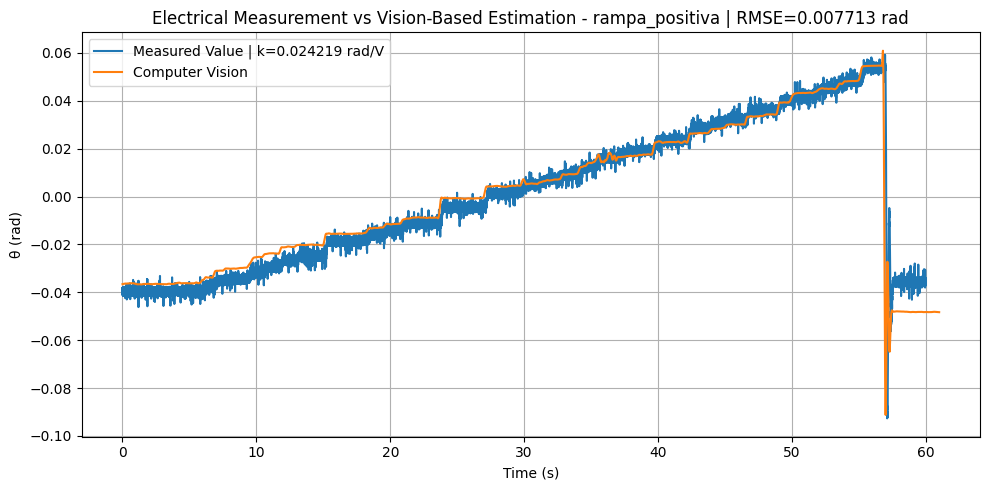

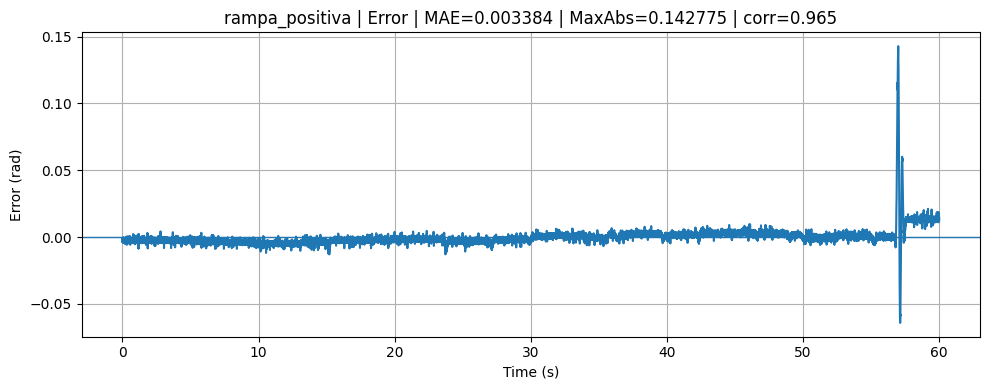


Comparation of theta: random_steps


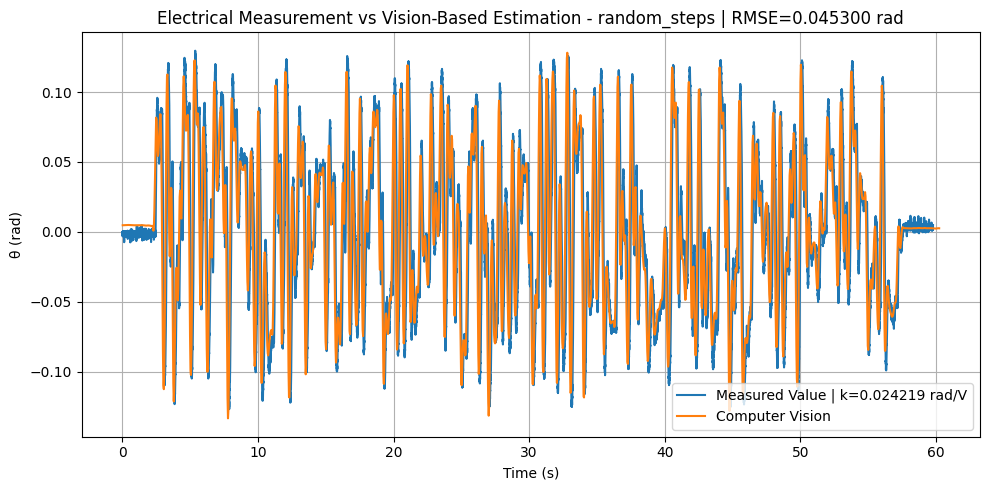

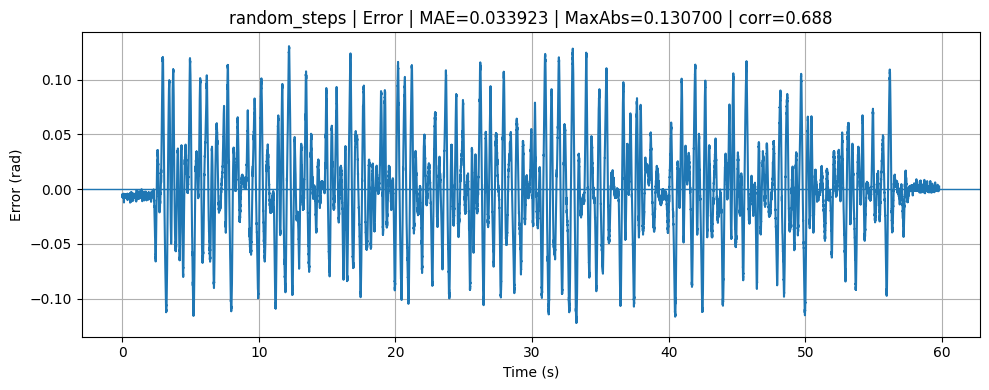


Comparation of theta: swept_sine


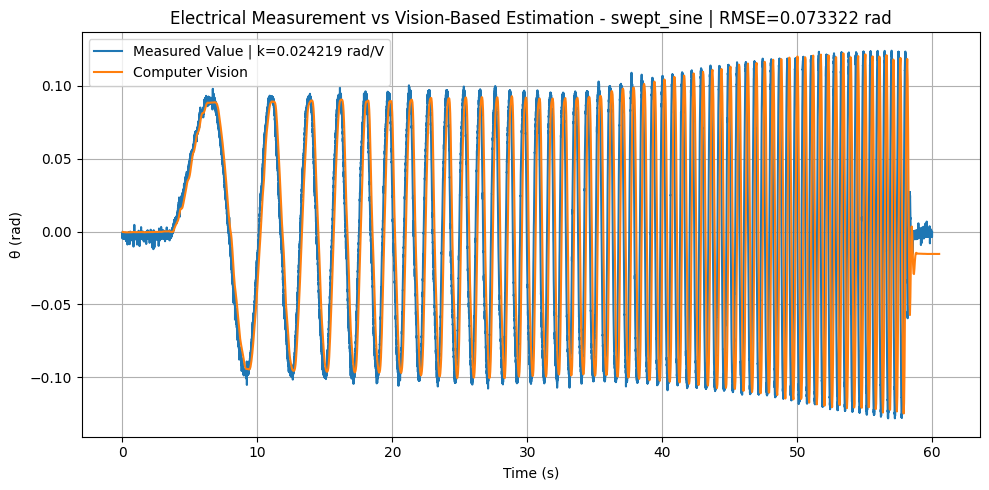

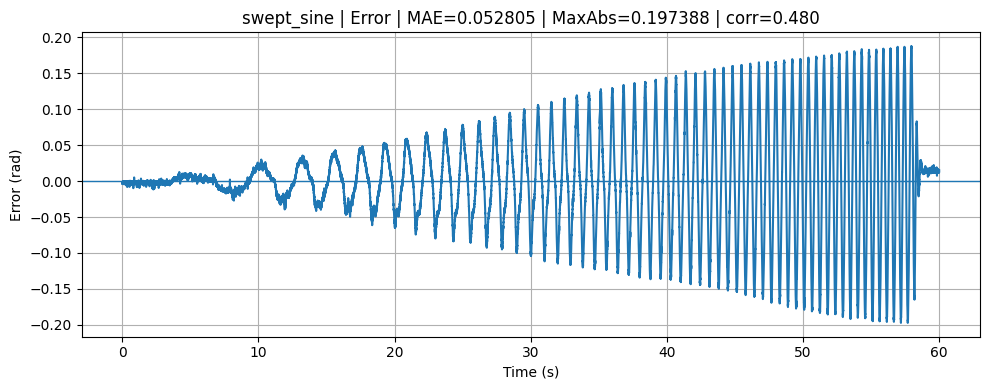

,test,k_rad_per_V,rmse,mae,max_abs,bias,corr,video_col,video_start_s,video_end_s,video_offset_s
0,rampa_positiva,0.024219,0.007713,0.003384,0.142775,-9.473745e-19,0.965304,theta_f_rad,12.00,73.0,-12.00
1,random_steps,0.024219,0.045300,0.033923,0.130700,2.135580e-19,0.687768,theta_f_rad,6.75,67.0,-6.75
2,swept_sine,0.024219,0.073322,0.052805,0.197388,-4.975458e-18,0.479919,theta_f_rad,6.48,67.0,-6.48


Theta summary saved to: C:\Users\edoal\ProjetosPy\bab_dlc1\results\tables\summary_theta_metrics_rad.csv


In [18]:
theta_metrics = []

for cfg in tests:
    name = cfg["name"]

    print(f"\nComparation of theta: {name}")

    mets = compare_theta_like(
        name=name,
        mat_path=cfg["mat_path"],
        video_csv=generated_csvs[name],
        fps=FPS,
        out_dir=THETA_VALIDATION_DIR,
        mat_use_filtered=False,
        video_use_filtered=True,
        video_start_s=cfg["video_start_s"],
        video_end_s=cfg["video_end_s"],
        video_offset_s=cfg["video_offset_s"],
        k_global=k_global,
        remove_dc_before_error=True,
        show=True
    )

    theta_metrics.append(mets)

df_theta_summary = pd.DataFrame(theta_metrics)
display(df_theta_summary)

theta_summary_csv = TABLES_DIR / "summary_theta_metrics_rad.csv"
df_theta_summary.to_csv(theta_summary_csv, index=False)

print("Theta summary saved to:", theta_summary_csv)

## Video \( \omega \) Plots

The angular velocity from the video is obtained from the numerical derivative of the already aligned $\theta_{video}$ used in the comparison.

## Cell 13 — $\omega$ Plots for the Three Experiments

Plotting video angular velocity: rampa_positiva


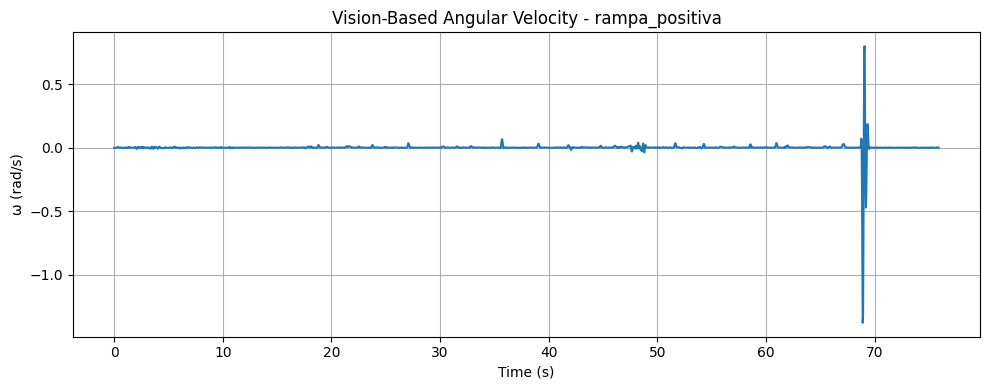

Figure saved in: C:\Users\edoal\ProjetosPy\bab_dlc1\results\figures\omega_video_rampa_positiva.png
Plotting video angular velocity: random_steps


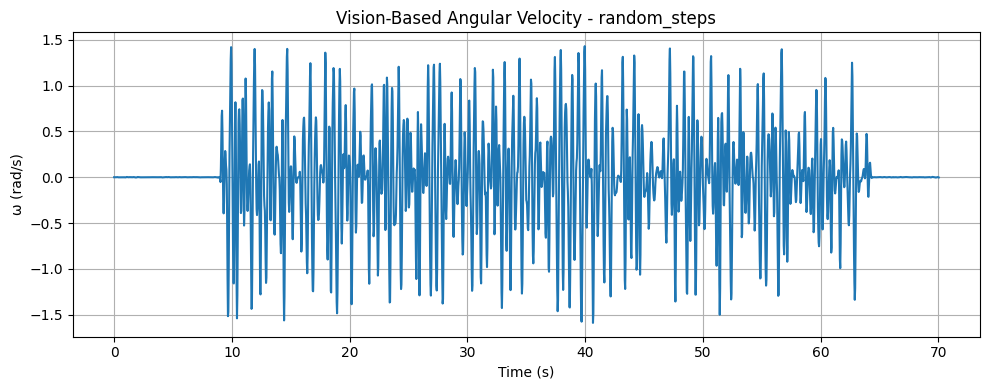

Figure saved in: C:\Users\edoal\ProjetosPy\bab_dlc1\results\figures\omega_video_random_steps.png
Plotting video angular velocity: swept_sine


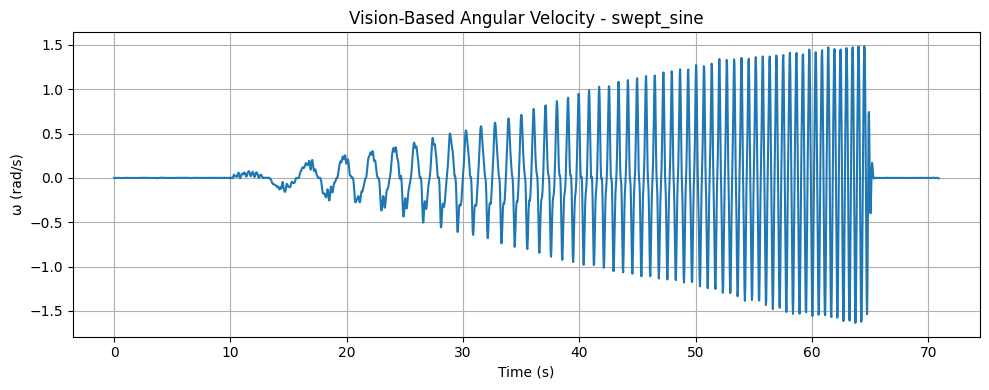

Figure saved in: C:\Users\edoal\ProjetosPy\bab_dlc1\results\figures\omega_video_swept_sine.png


In [20]:
for cfg in tests:
    name = cfg["name"]
    csv_path = generated_csvs[name]

    print(f"Plotting video angular velocity: {name}")

    df = pd.read_csv(csv_path)

    # optional: use only valid frames
    if "good" in df.columns:
        df = df[df["good"] == 1]

    t = df["t_s"]
    omega = df["omega_rad_s"]

    plt.figure(figsize=(10,4))
    plt.plot(t, omega)
    plt.xlabel("Time (s)")
    plt.ylabel("ω (rad/s)")
    plt.title(f"Vision-Based Angular Velocity - {name}")
    plt.grid(True)
    plt.tight_layout()

    fig_path = FIGURES_DIR / f"omega_video_{name}.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")

    plt.show()

    print("Figure saved in:", fig_path)

## Cell 14 — Generate 3×3 Grid from the Labeled Test Video

For other videos, simply modify the file path.

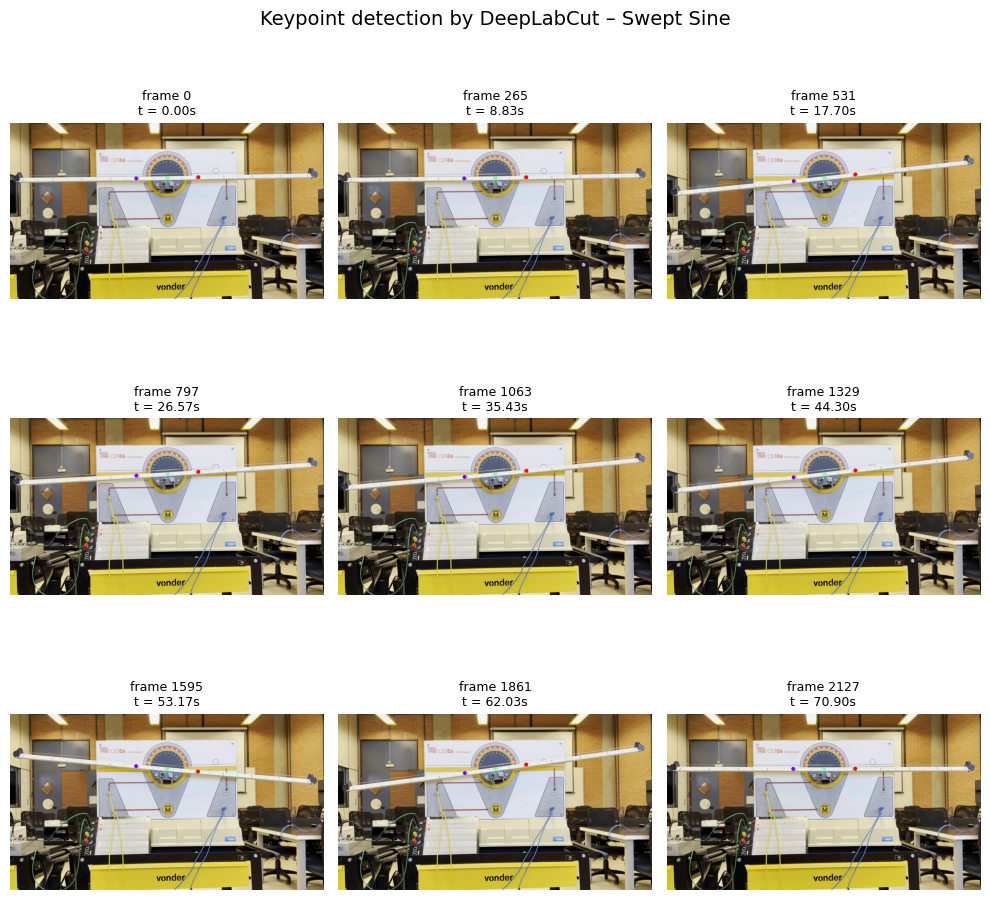

Figure saved in: C:\Users\edoal\ProjetosPy\bab_dlc1\results\figures\swept_sine_labeled_grid.png


In [21]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# path to the labeled video (adjust if necessary)
video_labeled = VIDEOS_DIR / "swept_sine_readyDLC_Resnet50_bab_bar_onlyMar8shuffle1_snapshot_100_p60_labeled.mp4"

cap = cv2.VideoCapture(str(video_labeled))

if not cap.isOpened():
    raise RuntimeError(f"Failed to open the video: {video_labeled}")

fps = cap.get(cv2.CAP_PROP_FPS)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# select 9 frames along the video
indices = np.linspace(0, total_frames - 1, 9).astype(int)

frames = []
times = []

for idx in indices:
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()

    if ret:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(frame)
        times.append(idx / fps)

cap.release()

# ======================
# Plot grid
# ======================

fig, axes = plt.subplots(3, 3, figsize=(10, 10))

for ax, frame, idx, t in zip(axes.flatten(), frames, indices, times):
    ax.imshow(frame)
    ax.set_title(f"frame {idx}\nt = {t:.2f}s", fontsize=9)
    ax.axis("off")

plt.suptitle("Keypoint detection by DeepLabCut – Swept Sine", fontsize=14)

plt.tight_layout()

out_path = FIGURES_DIR / "swept_sine_labeled_grid.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved in:", out_path)